In [15]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier

# Create output directories if they don't exist
Path("work/outputs").mkdir(parents=True, exist_ok=True)
Path("work/figures").mkdir(parents=True, exist_ok=True)

# Load dataset
possible_paths = [
    "data/raw/content_refresh_anonymized.csv",
    "../../data/raw/content_refresh_anonymized.csv",
    "../data/raw/content_refresh_anonymized.csv"
]
csv_path = next(p for p in possible_paths if os.path.exists(p))
df = pd.read_csv(csv_path)

# Label definition
df["is_declining_label"] = (df["trend_direction"].str.lower() == "down").astype(int)

print(f"Loaded {len(df):,} rows.")


Loaded 30,000 rows.


# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [16]:
# 1. Feature selection & model training
feature_cols = [
    "impressions_90d", "clicks_90d", "avg_position", 
    "content_age_days", "days_since_last_update", 
    "word_count", "ctr"
]
X = df[feature_cols].fillna(df[feature_cols].median())
y = df["is_declining_label"]

rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42).fit(X, y)
df["model_decline_prob"] = rf_model.predict_proba(X)[:, 1]

# 2. Reason Code generator
def assign_reasons(row):
    reasons = []
    if row["days_since_last_update"] >= 180 and row["impressions_90d"] >= 500:
        reasons.append("stale_visible_page")
    if 0 < row["avg_position"] <= 10:
        reasons.append("page_one_decay_risk")
    if row["word_count"] > 0 and row["word_count"] < 1200:
        reasons.append("thin_content_gap")
    if row["ctr"] < 0.5 and row["impressions_90d"] >= 500:
        reasons.append("low_ctr_visible")
    return "|".join(reasons) if reasons else "general_momentum_loss"

df["reason_codes"] = df.apply(assign_reasons, axis=1)

# 3. Action Prescriber mapping
def prescribe_action(row):
    reasons = set(row["reason_codes"].split("|"))
    if "thin_content_gap" in reasons:
        return "expand_and_update"
    elif "low_ctr_visible" in reasons:
        return "optimize_title_and_snippet"
    elif "stale_visible_page" in reasons or "page_one_decay_risk" in reasons:
        return "refresh_stats_and_links"
    else:
        return "monitor_traffic"

df["prescribed_action"] = df.apply(prescribe_action, axis=1)

# 4. Rank queue by model probability
df["playbook_rank"] = df["model_decline_prob"].rank(method="first", ascending=False).astype(int)
queue = df.sort_values("playbook_rank")

print("Top 5 Playbook Queue Items:")
print(queue[['playbook_rank', 'content_id', 'model_decline_prob', 'reason_codes', 'prescribed_action']].head(5).to_string(index=False))


Top 5 Playbook Queue Items:
 playbook_rank           content_id  model_decline_prob                        reason_codes          prescribed_action
             1 content_4d76cdb3387b            0.895648 page_one_decay_risk|low_ctr_visible optimize_title_and_snippet
             2 content_04f9c8cfb061            0.895391 page_one_decay_risk|low_ctr_visible optimize_title_and_snippet
             3 content_b51e2e4d22ff            0.894485                     low_ctr_visible optimize_title_and_snippet
             4 content_e04eb9549989            0.893728 page_one_decay_risk|low_ctr_visible optimize_title_and_snippet
             5 content_9b6df29f7889            0.889717 page_one_decay_risk|low_ctr_visible optimize_title_and_snippet


Ranked Action Logic:

Model Priority: The Random Forest model orders the pages by predicted probability of decline (model_decline_prob).

Reason Codes & Actions:

Deterministic business logic attaches human-readable tags and maps them to concrete editing tasks (expand_and_update, optimize_title_and_snippet, refresh_stats_and_links).

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

Intended Use & System Boundaries:

Intended Use: 
Decision-support queue for FlyRank content editors to prioritize weekly article refreshes.

System Limits:

1. Cross-Sectional Limitation: The queue identifies pages associated with past traffic decline; it does not guarantee causal impact post-refresh.
2. Domain Boundary: Designed for organic Google search performance; does not account for paid ad campaigns or viral social media traffic spikes.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

Human Review Protocol & The No-Go List:

Human Acceptance Criteria:

A human editor must inspect every flagged page before editing to verify:

The topic has verifiable outdated information (e.g. outdated year/stats).
The low CTR is not due to a SERP feature (e.g. Google direct answer box).

The No-Go List (NEVER Automate):

New Pages (<30 days old): Need time to settle in Google indexing.

Legal & Privacy Policies: Static compliance documents must never be edited for SEO.

Active A/B Test Pages: Pages currently undergoing CRO or metadata experiments.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

Two-Clock Monitoring & Safety Triggers:

Clock 1: Pre-Release Monitoring (Data Distribution & Schema Checks)

    Trigger alert if missing value rate in impressions_90d or avg_position exceeds 5%.

    Trigger alert if feature distribution drifts by >15% compared to training baseline.

Clock 2: Post-Label Outcome Monitoring (Validation Window)

    Retrain trigger: If Precision@50 on a 30-day forward rolling window drops below 0.55.

    Retrain trigger: Schedule mandatory monthly retrains as new daily search partitions arrive

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Exported queue to: work/outputs/content_action_playbook_queue.csv


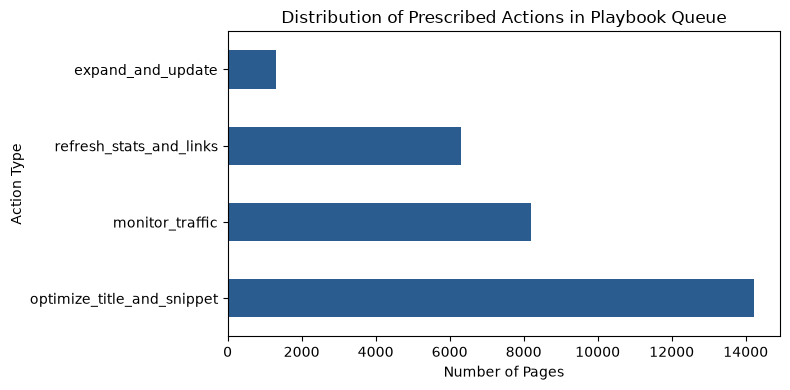

Saved figure to: work/figures/action_distribution.png


In [17]:
from pathlib import Path
import matplotlib.pyplot as plt

# 1. Determine output directory paths relative to repository root
output_dir = Path("work/outputs")
figures_dir = Path("work/figures")

# If running from inside work/notebooks/, adjust relative paths
if not output_dir.exists() and Path("../outputs").parent.exists():
    output_dir = Path("../outputs")
    figures_dir = Path("../figures")

# Ensure parent directories exist
output_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

# 2. Export Action Playbook Queue CSV
export_cols = [
    "playbook_rank", "content_id", "client_id", "model_decline_prob", 
    "reason_codes", "prescribed_action", "impressions_90d", "avg_position", 
    "days_since_last_update", "is_declining_label"
]
output_csv = output_dir / "content_action_playbook_queue.csv"
queue[export_cols].to_csv(output_csv, index=False)
print(f"Exported queue to: {output_csv}")

# 3. Export Action Mix Chart for Paper
plt.figure(figsize=(8, 4))
queue["prescribed_action"].value_counts().plot(kind="barh", color="#2b5c8f")
plt.title("Distribution of Prescribed Actions in Playbook Queue")
plt.xlabel("Number of Pages")
plt.ylabel("Action Type")
plt.tight_layout()

fig_path = figures_dir / "action_distribution.png"
plt.savefig(fig_path, dpi=300)
plt.show()
print(f"Saved figure to: {fig_path}")


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.